In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from IPython.display import display
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [15]:
print("="*70)
print("DATA LOADING AND INITIAL INSPECTION")
print("="*70)

df = pd.read_csv("customer_data.csv")

print("First 5 rows of the dataset:")
display(df.head())

print("Dataset Information:")
print(df.info())

print("Summary Statistics:")
display(df.describe())

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

DATA LOADING AND INITIAL INSPECTION
First 5 rows of the dataset:


,CustomerID,Age,Gender,Income,Tenure,ProductType,SupportCalls,ChurnStatus
0,CUST0000,59.0,0,151203.0,4.0,0,1.0,0
1,CUST0001,69.0,0,58332.0,6.0,1,9.0,0
2,CUST0002,46.0,1,149481.0,2.0,0,12.0,0
3,CUST0003,32.0,1,115937.0,1.0,1,13.0,0
4,CUST0004,60.0,0,103929.0,4.0,1,5.0,0


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CustomerID    3500 non-null   object 
 1   Age           3325 non-null   float64
 2   Gender        3500 non-null   int64  
 3   Income        3328 non-null   float64
 4   Tenure        3325 non-null   float64
 5   ProductType   3500 non-null   int64  
 6   SupportCalls  3329 non-null   float64
 7   ChurnStatus   3500 non-null   int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 218.9+ KB
None
Summary Statistics:


,Age,Gender,Income,Tenure,ProductType,SupportCalls,ChurnStatus
count,3325.000000,3500.000000,3.328000e+03,3325.000000,3500.000000,3329.000000,3500.000000
mean,43.606617,0.495714,1.406860e+05,5.041504,0.298857,10.078702,0.044857
std,14.931487,0.500053,4.333271e+05,2.571029,0.457822,21.735374,0.207020
min,14.000000,0.000000,2.503700e+04,0.000000,0.000000,1.000000,0.000000
25%,31.000000,0.000000,5.653025e+04,3.000000,0.000000,3.000000,0.000000
50%,43.000000,0.000000,8.953250e+04,5.000000,0.000000,7.000000,0.000000
75%,56.000000,1.000000,1.215025e+05,7.000000,1.000000,11.000000,0.000000
max,69.000000,1.000000,5.004849e+06,9.000000,1.000000,200.000000,1.000000


Dataset shape: 3500 rows, 8 columns


In [16]:
print("" + "="*70)
print("HANDLING MISSING DATA (NUMERIC FEATURES ONLY)")
print("="*70)

print("Missing values before handling:")
missing_before = df.isnull().sum()
print(missing_before)
total_missing = missing_before.sum()
print(f"Total missing values: {total_missing}")
if total_missing == 0:
    print("No missing values detected!")
else:
    print("Handling strategy:")
    print("• Numeric columns: impute with median (robust against outliers)")
    print("• Non-numeric columns: left unchanged (already complete)")
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    medians = df[numeric_cols].median()
    df[numeric_cols] = df[numeric_cols].fillna(medians)
    print(f"Imputed {len(numeric_cols)} numerical columns with median")

print("Missing values after handling:")
print(df.isnull().sum())
print("✓ Numeric missing values resolved; categorical features untouched.")

HANDLING MISSING DATA (NUMERIC FEATURES ONLY)
Missing values before handling:
CustomerID        0
Age             175
Gender            0
Income          172
Tenure          175
ProductType       0
SupportCalls    171
ChurnStatus       0
dtype: int64
Total missing values: 693
Handling strategy:
• Numeric columns: impute with median (robust against outliers)
• Non-numeric columns: left unchanged (already complete)
Imputed 7 numerical columns with median
Missing values after handling:
CustomerID      0
Age             0
Gender          0
Income          0
Tenure          0
ProductType     0
SupportCalls    0
ChurnStatus     0
dtype: int64
✓ Numeric missing values resolved; categorical features untouched.


In [17]:
print("" + "="*70)
print("STEP 3: HANDLING OUTLIERS")
print("="*70)

print("Outlier Detection using Z-score method (|Z| > 3):")

# Specify only the desired numeric columns
numeric_cols = ['Age', 'Income', 'Tenure', 'SupportCalls']
outliers_zscore = {}

for col in numeric_cols:
    if col in df.columns:  # Check if column exists in DataFrame
        z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
        outliers = (z_scores > 3).sum()
        outliers_zscore[col] = outliers
        print(f"  {col}: {outliers} outliers")
    else:
        print(f"  {col}: column not found in DataFrame")

print("Outlier detection completed using Z-score method.")


STEP 3: HANDLING OUTLIERS
Outlier Detection using Z-score method (|Z| > 3):
  Age: 0 outliers
  Income: 50 outliers
  Tenure: 0 outliers
  SupportCalls: 70 outliers
Outlier detection completed using Z-score method.


In [18]:
# Outlier handling using Capping Method
print("=" * 50)
print("HANDLING OUTLIERS - CAPPING METHOD")
print("=" * 50)

# Select only numeric columns
numeric_cols = ['Age', 'Income', 'Tenure', 'SupportCalls']

print(f"Applying capping to {len(numeric_cols)} numeric columns...")

for col in numeric_cols:
    # Calculate the 1st and 99th percentiles
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.98)
    
    # Count outliers before capping
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    if outliers_count > 0:
        print(f"{col}:")
        print(f"  - Capping range: [{lower_bound:.2f}, {upper_bound:.2f}]")

        # Cap the values
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"  - ✓ Outliers capped successfully")

print("" + "=" * 50)
print("OUTLIER CAPPING COMPLETED")
print("=" * 50)
# detect outliers again after capping
print("Outlier Detection using Z-score method (|Z| > 3) after caping:")

# Specify only the desired numeric columns
numeric_cols = ['Age', 'Income', 'Tenure', 'SupportCalls']
outliers_zscore = {}

for col in numeric_cols:
    if col in df.columns:  # Check if column exists in DataFrame
        z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
        outliers = (z_scores > 3).sum()
        outliers_zscore[col] = outliers
        print(f"  {col}: {outliers} outliers")
    else:
        print(f"  {col}: column not found in DataFrame")

print("Outlier detection completed using Z-score method.")



HANDLING OUTLIERS - CAPPING METHOD
Applying capping to 4 numeric columns...
Age:
  - Capping range: [18.00, 68.00]
  - ✓ Outliers capped successfully
Income:
  - Capping range: [26241.72, 168921.78]
  - ✓ Outliers capped successfully
Tenure:
  - Capping range: [1.00, 9.00]
  - ✓ Outliers capped successfully
SupportCalls:
  - Capping range: [1.00, 15.72]
  - ✓ Outliers capped successfully
OUTLIER CAPPING COMPLETED
Outlier Detection using Z-score method (|Z| > 3) after caping:
  Age: 0 outliers
  Income: 0 outliers
  Tenure: 0 outliers
  SupportCalls: 0 outliers
Outlier detection completed using Z-score method.


In [19]:
print("" + "="*70)
print("FEATURE SCALING")
print("="*70)

print("Feature Scaling Strategy:")
print("Method: Min-Max Normalization")
print("Formula: X_scaled = (X - X_min) / (X_max - X_min)")
print("Range: [0, 1]")

# Specify only the desired columns for scaling
cols_to_scale = ['Age', 'Income', 'Tenure', 'SupportCalls']

# Keep only existing columns to avoid KeyErrors
cols_to_scale = [col for col in cols_to_scale if col in df.columns]

scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Scaled {len(cols_to_scale)} numerical features:")
print(f"Features scaled: {', '.join(cols_to_scale)}")

print("Scaled data preview:")
display(df.head())

print("Verification - Value ranges after scaling:")
print(df[cols_to_scale].describe().loc[['min', 'max']])


FEATURE SCALING
Feature Scaling Strategy:
Method: Min-Max Normalization
Formula: X_scaled = (X - X_min) / (X_max - X_min)
Range: [0, 1]
Scaled 4 numerical features:
Features scaled: Age, Income, Tenure, SupportCalls
Scaled data preview:


,CustomerID,Age,Gender,Income,Tenure,ProductType,SupportCalls,ChurnStatus
0,CUST0000,0.82,0,0.875815,0.375,0,0.000000,0
1,CUST0001,1.00,0,0.224911,0.625,1,0.543478,0
2,CUST0002,0.56,1,0.863746,0.125,0,0.747283,0
3,CUST0003,0.28,1,0.628646,0.000,1,0.815217,0
4,CUST0004,0.84,0,0.544486,0.375,1,0.271739,0


Verification - Value ranges after scaling:
     Age  Income  Tenure  SupportCalls
min  0.0     0.0     0.0           0.0
max  1.0     1.0     1.0           1.0


UNIVARIATE ANALYSIS - NUMERICAL FEATURES


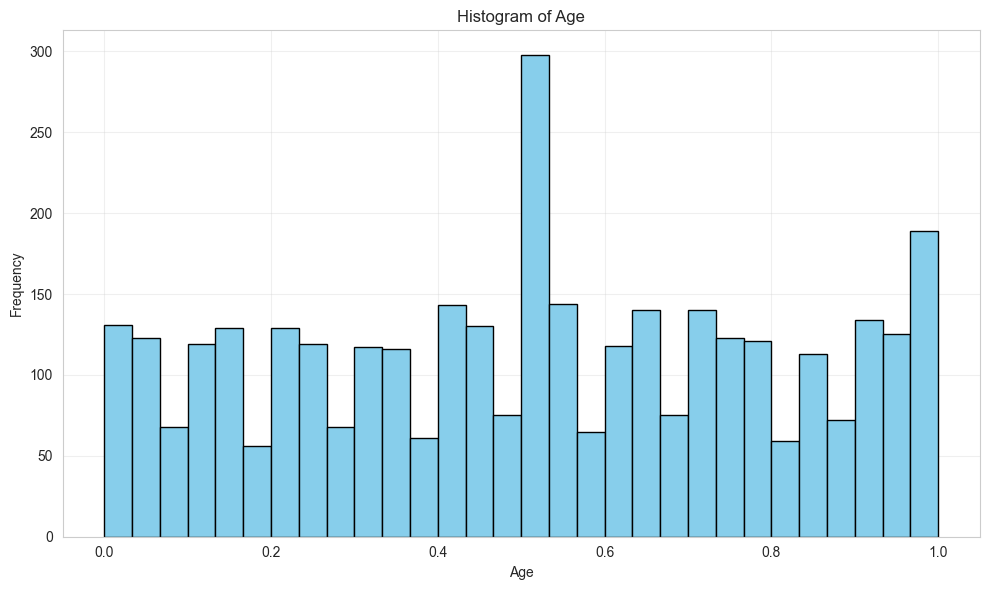

Age - Summary Statistics:
count    3500.000000
mean        0.511211
std         0.290436
min         0.000000
25%         0.280000
50%         0.500000
75%         0.760000
max         1.000000
Name: Age, dtype: float64
------------------------------------------------------------


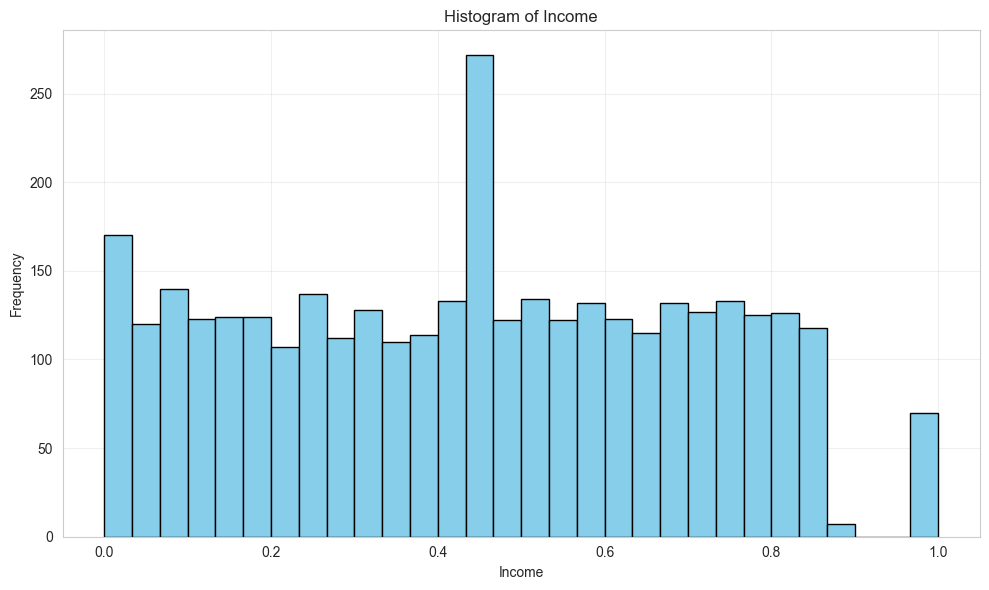

Income - Summary Statistics:
count    3500.000000
mean        0.441676
std         0.259359
min         0.000000
25%         0.225040
50%         0.443585
75%         0.656490
max         1.000000
Name: Income, dtype: float64
------------------------------------------------------------


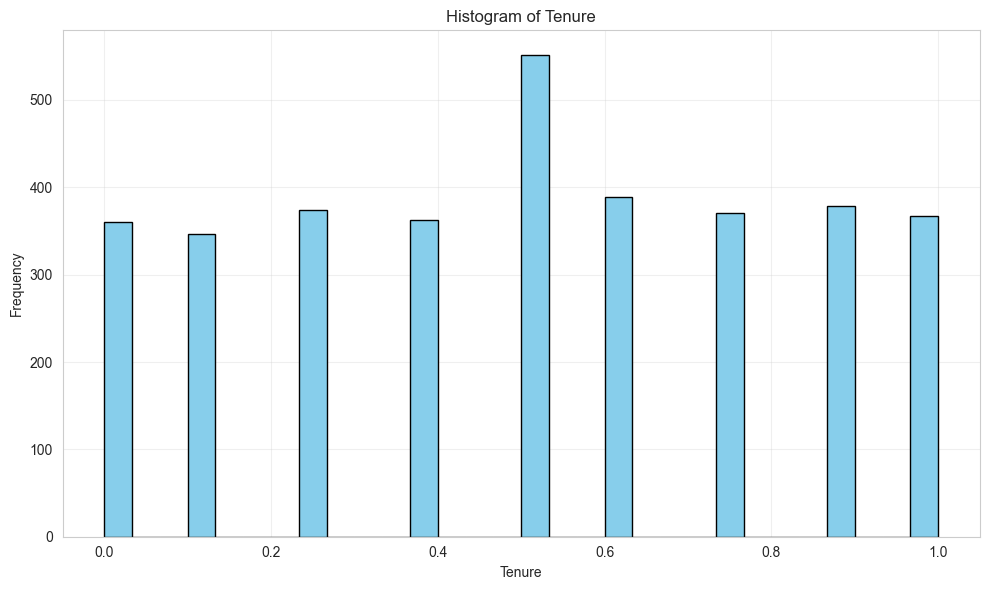

Tenure - Summary Statistics:
count    3500.000000
mean        0.505286
std         0.312593
min         0.000000
25%         0.250000
50%         0.500000
75%         0.750000
max         1.000000
Name: Tenure, dtype: float64
------------------------------------------------------------


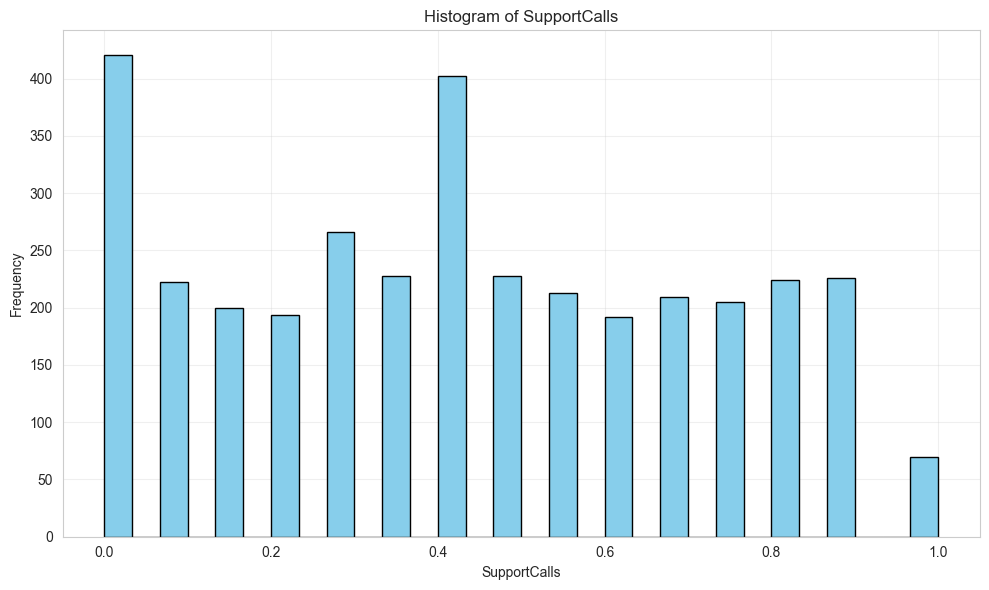

SupportCalls - Summary Statistics:
count    3500.000000
mean        0.424095
std         0.287062
min         0.000000
25%         0.203804
50%         0.407609
75%         0.679348
max         1.000000
Name: SupportCalls, dtype: float64
------------------------------------------------------------
UNIVARIATE ANALYSIS - CATEGORICAL FEATURES


C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\202127340.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='Set2')


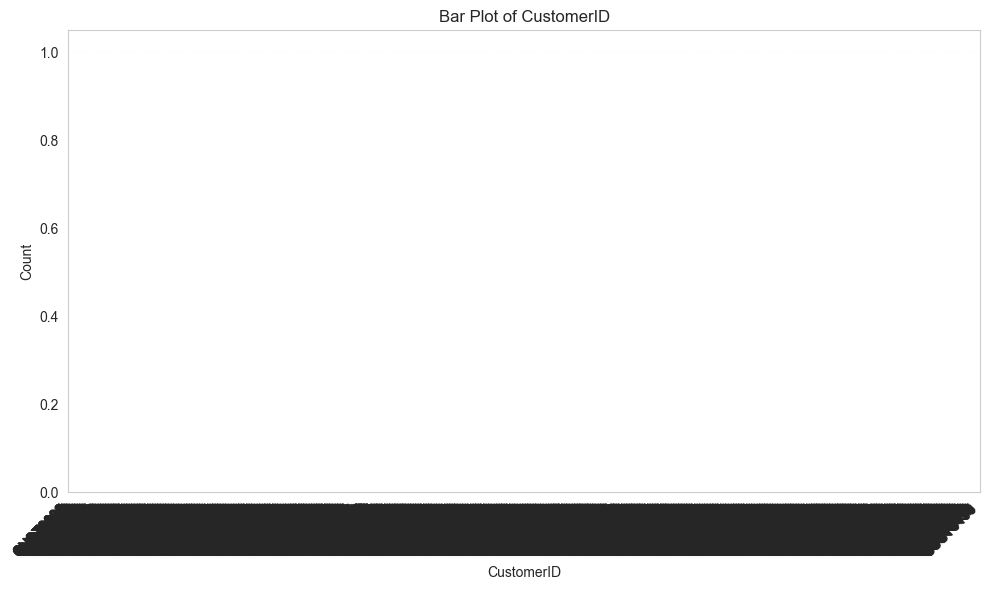

CustomerID - Value Counts:
CustomerID
CUST0000    1
CUST0001    1
CUST0002    1
CUST0003    1
CUST0004    1
           ..
CUST3495    1
CUST3496    1
CUST3497    1
CUST3498    1
CUST3499    1
Name: count, Length: 3500, dtype: int64
CustomerID - Percentages:
CustomerID
CUST0000    0.028571
CUST0001    0.028571
CUST0002    0.028571
CUST0003    0.028571
CUST0004    0.028571
              ...   
CUST3495    0.028571
CUST3496    0.028571
CUST3497    0.028571
CUST3498    0.028571
CUST3499    0.028571
Name: proportion, Length: 3500, dtype: float64
------------------------------------------------------------


C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\202127340.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='Set2')


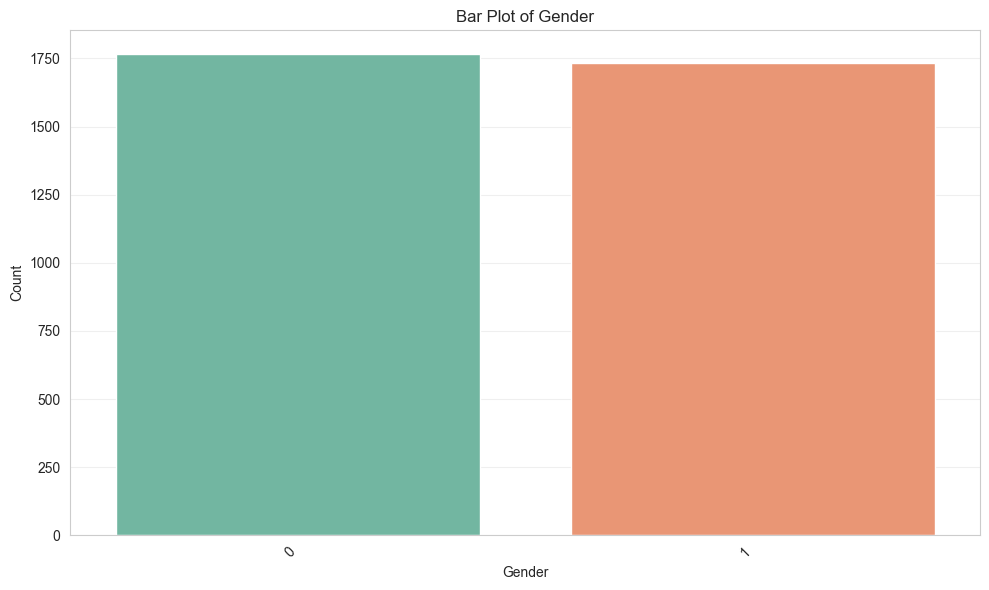

Gender - Value Counts:
Gender
0    1765
1    1735
Name: count, dtype: int64
Gender - Percentages:
Gender
0    50.428571
1    49.571429
Name: proportion, dtype: float64
------------------------------------------------------------


C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\202127340.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='Set2')


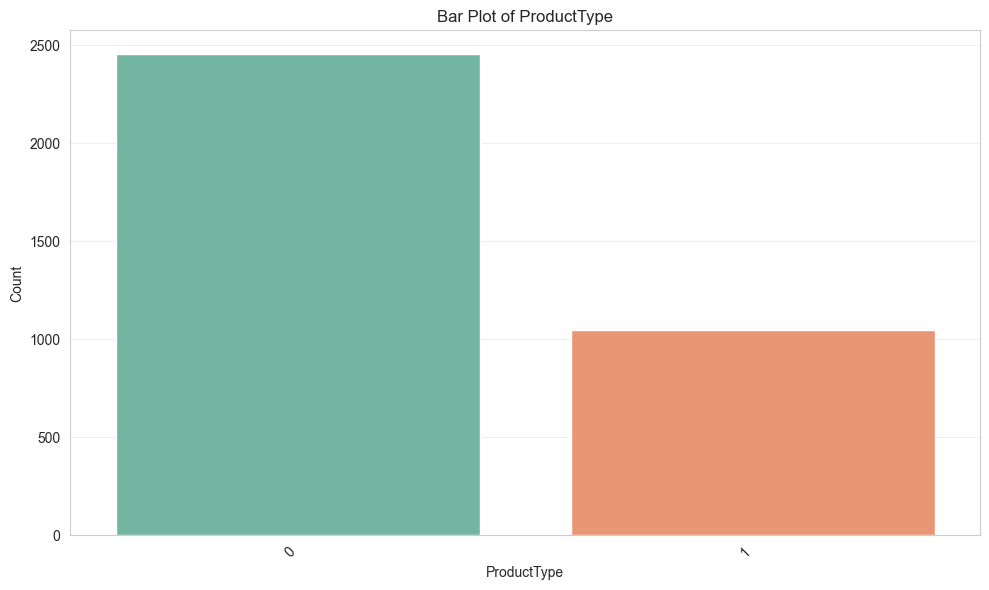

ProductType - Value Counts:
ProductType
0    2454
1    1046
Name: count, dtype: int64
ProductType - Percentages:
ProductType
0    70.114286
1    29.885714
Name: proportion, dtype: float64
------------------------------------------------------------


C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\202127340.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='Set2')


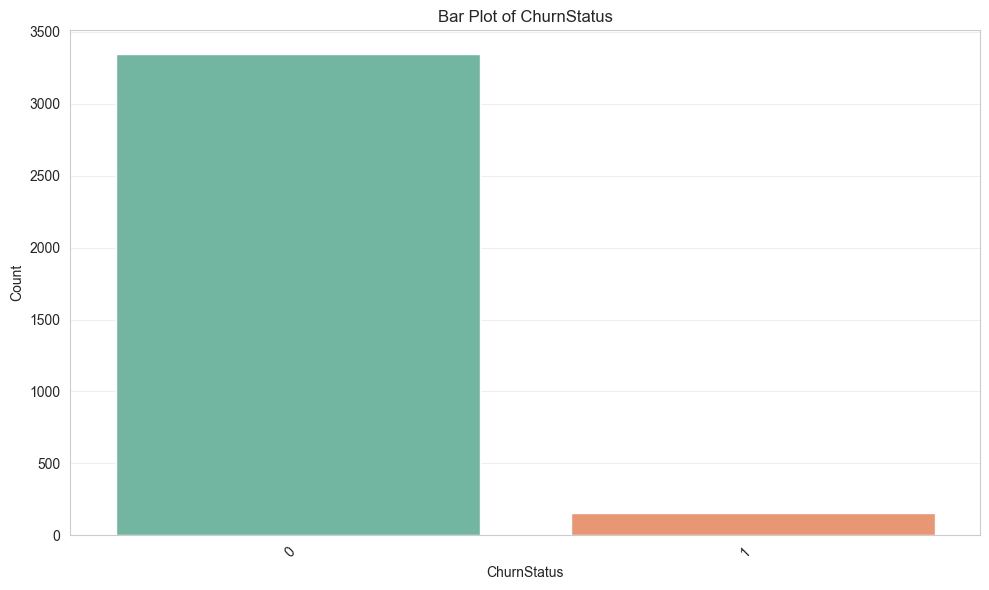

ChurnStatus - Value Counts:
ChurnStatus
0    3343
1     157
Name: count, dtype: int64
ChurnStatus - Percentages:
ChurnStatus
0    95.514286
1     4.485714
Name: proportion, dtype: float64
------------------------------------------------------------


In [27]:
numeric_cols = ['Age', 'Income', 'Tenure', 'SupportCalls']

# Get categorical columns (all columns except numerical ones)
categorical_cols = [col for col in df.columns if col not in numeric_cols]

# Set the style for better-looking plots
sns.set_style("whitegrid")

# ===== UNIVARIATE ANALYSIS FOR NUMERICAL FEATURES =====
print("=" * 60)
print("UNIVARIATE ANALYSIS - NUMERICAL FEATURES")
print("=" * 60)

for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    
    # Histogram
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"{col} - Summary Statistics:")
    print(df[col].describe())
    print("-" * 60)

# ===== UNIVARIATE ANALYSIS FOR CATEGORICAL FEATURES =====
print("" + "=" * 60)
print("UNIVARIATE ANALYSIS - CATEGORICAL FEATURES")
print("=" * 60)

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    
    # Bar plot
    value_counts = df[col].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='Set2')
    plt.title(f'Bar Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print value counts and percentages
    print(f"{col} - Value Counts:")
    print(value_counts)
    print(f"{col} - Percentages:")
    print(df[col].value_counts(normalize=True) * 100)
    print("-" * 60)

[5.1] BIVARIATE ANALYSIS
▸ Numeric features vs ChurnStatus (box + strip plots)


C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


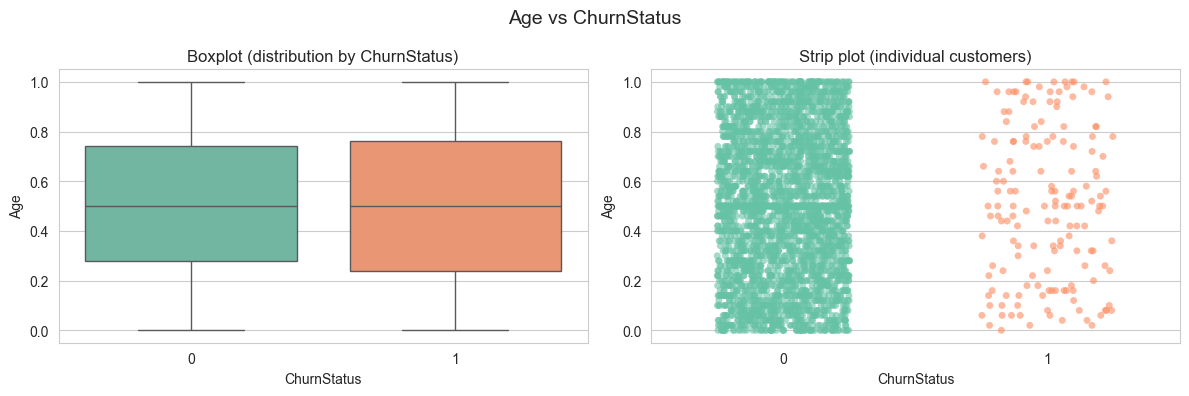

C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


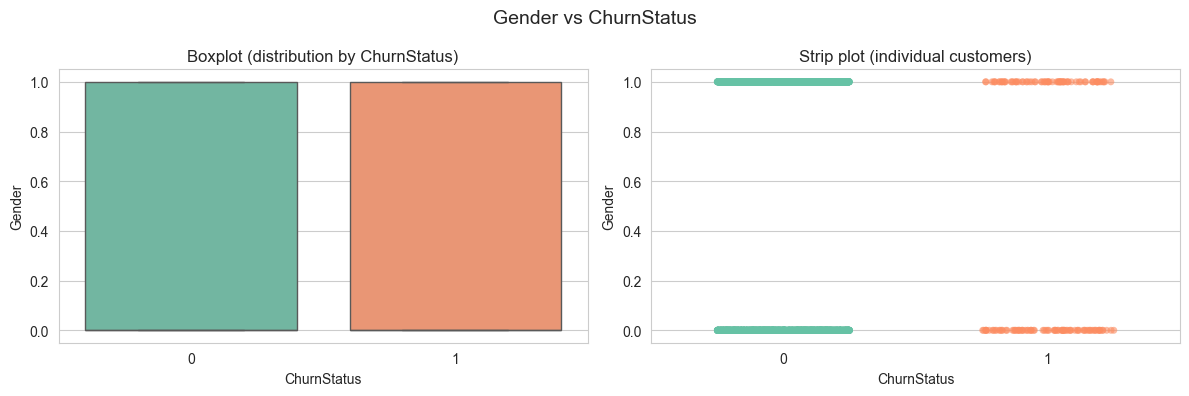

C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


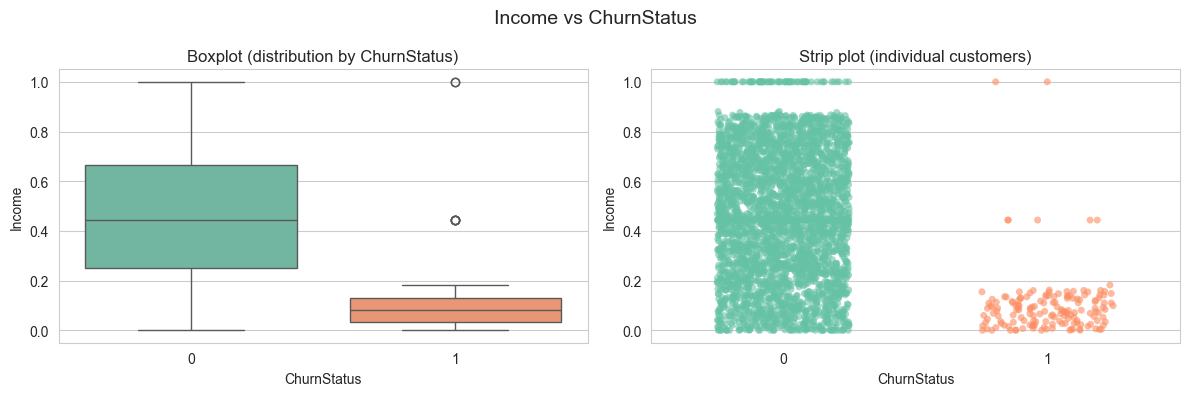

C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


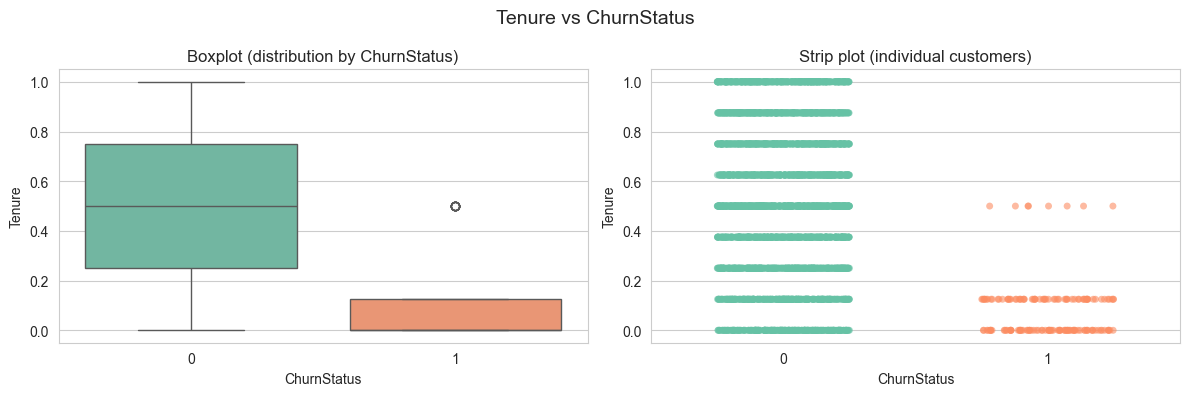

C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


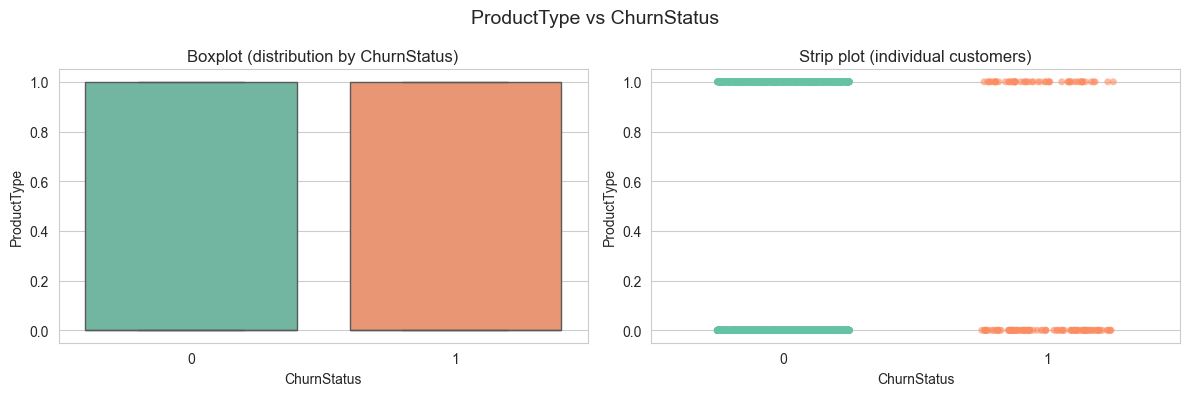

C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
C:\Users\hassa\AppData\Local\Temp\ipykernel_24604\2020642346.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


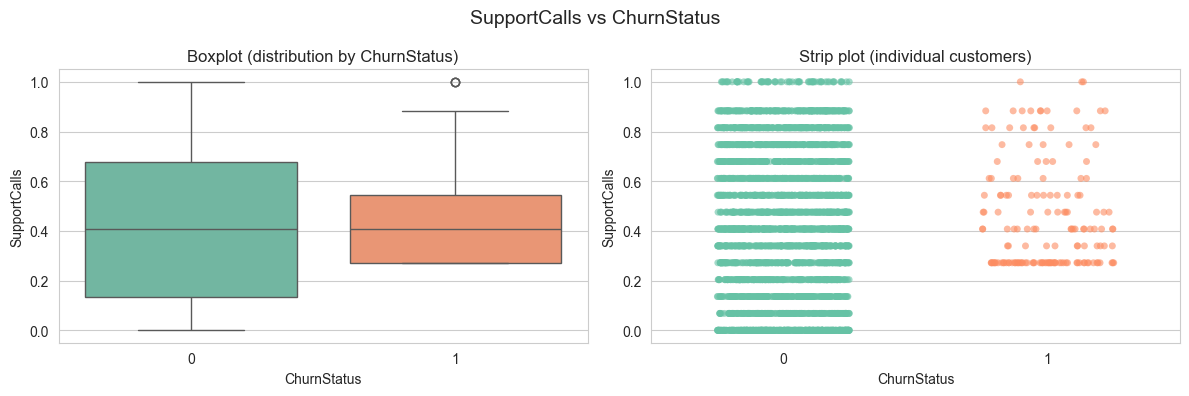

▸ Categorical features vs ChurnStatus (count + churn rate)
  • Skipping CustomerID: too many unique categories for a clean plot.
Bivariate analysis completed. Keep an eye out for features where churn behaves differently—those can be golden nuggets for modeling!


In [21]:
target_col = "ChurnStatus"

# Separate numeric and categorical predictors, guarding against missing target
numeric_cols = df.select_dtypes(include="number").columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

print("[5.1] BIVARIATE ANALYSIS")

# ----- Numeric features vs ChurnStatus: box + strip plots -----
print("▸ Numeric features vs ChurnStatus (box + strip plots)")
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)
    fig.suptitle(f"{col} vs {target_col}", fontsize=14)

    sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
    axes[0].set_title("Boxplot (distribution by ChurnStatus)")
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel(col)

    sns.stripplot(
        data=df,
        x=target_col,
        y=col,
        ax=axes[1],
        palette="Set2",
        jitter=0.25,
        alpha=0.6
    )
    axes[1].set_title("Strip plot (individual customers)")
    axes[1].set_xlabel(target_col)
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

# ----- Categorical features vs ChurnStatus: stacked bar + churn rate -----
print("▸ Categorical features vs ChurnStatus (count + churn rate)")
for col in categorical_cols:
    # Skip columns with too many distinct values to keep visuals readable
    if df[col].nunique(dropna=False) > 20:
        print(f"  • Skipping {col}: too many unique categories for a clean plot.")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"{col} vs {target_col}", fontsize=14)

    # Count by category and churn status
    sns.countplot(data=df, x=col, hue=target_col, palette="Set2", ax=axes[0])
    axes[0].set_title("Count by ChurnStatus")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Customer count")
    axes[0].tick_params(axis="x", rotation=30, ha="right")

    # Churn rate (percentage) per category
    churn_rate = (
        df.groupby(col)[target_col]
        .value_counts(normalize=True)
        .rename("rate")
        .reset_index()
    )
    churn_rate = churn_rate[churn_rate[target_col] == 1]

    sns.barplot(data=churn_rate, x=col, y="rate", palette="Set2", ax=axes[1])
    axes[1].set_title("Churn rate by category")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Churn rate")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=30, ha="right")

    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="{:.0%}", padding=3)

    plt.tight_layout()
    plt.show()

print("Bivariate analysis completed. Keep an eye out for features where churn behaves differently—those can be golden nuggets for modeling!")

In [22]:
print("CORRELATION ANALYSIS")
print("-" * 70)

# Specify only the desired numeric columns + target
numeric_cols = ['Age', 'Income', 'Tenure', 'SupportCalls', 'ChurnStatus']

# Keep only columns that actually exist in the DataFrame
numeric_cols = [col for col in numeric_cols if col in df.columns]

print("Correlation Matrix:")
correlation_matrix = df[numeric_cols].corr()
display(correlation_matrix)

if 'ChurnStatus' in correlation_matrix.columns:
    print("Correlation with ChurnStatus (sorted by absolute value):")
    churn_corr = correlation_matrix['ChurnStatus'].sort_values(ascending=False)
    print(churn_corr)
    
    print("Interpretation:")
    positive_corr = churn_corr[churn_corr > 0].drop('ChurnStatus', errors='ignore')
    negative_corr = churn_corr[churn_corr < 0]
    
    if len(positive_corr) > 0:
        print("Positive correlation with churn (increases churn risk):")
        for feature, corr_val in positive_corr.items():
            print(f"  {feature}: {corr_val:.4f}")
    
    if len(negative_corr) > 0:
        print("Negative correlation with churn (decreases churn risk):")
        for feature, corr_val in negative_corr.items():
            print(f"  {feature}: {corr_val:.4f}")


CORRELATION ANALYSIS
----------------------------------------------------------------------
Correlation Matrix:


,Age,Income,Tenure,SupportCalls,ChurnStatus
Age,1.000000,-0.005875,-0.011269,0.045964,-0.002092
Income,-0.005875,1.000000,0.019496,0.005617,-0.285647
Tenure,-0.011269,0.019496,1.000000,0.029679,-0.296801
SupportCalls,0.045964,0.005617,0.029679,1.000000,0.026156
ChurnStatus,-0.002092,-0.285647,-0.296801,0.026156,1.000000


Correlation with ChurnStatus (sorted by absolute value):
ChurnStatus     1.000000
SupportCalls    0.026156
Age            -0.002092
Income         -0.285647
Tenure         -0.296801
Name: ChurnStatus, dtype: float64
Interpretation:
Positive correlation with churn (increases churn risk):
  SupportCalls: 0.0262
Negative correlation with churn (decreases churn risk):
  Age: -0.0021
  Income: -0.2856
  Tenure: -0.2968


STEP 6: DATA VISUALIZATIONS
Visualization 1: Distribution of Numerical Features (Histograms)


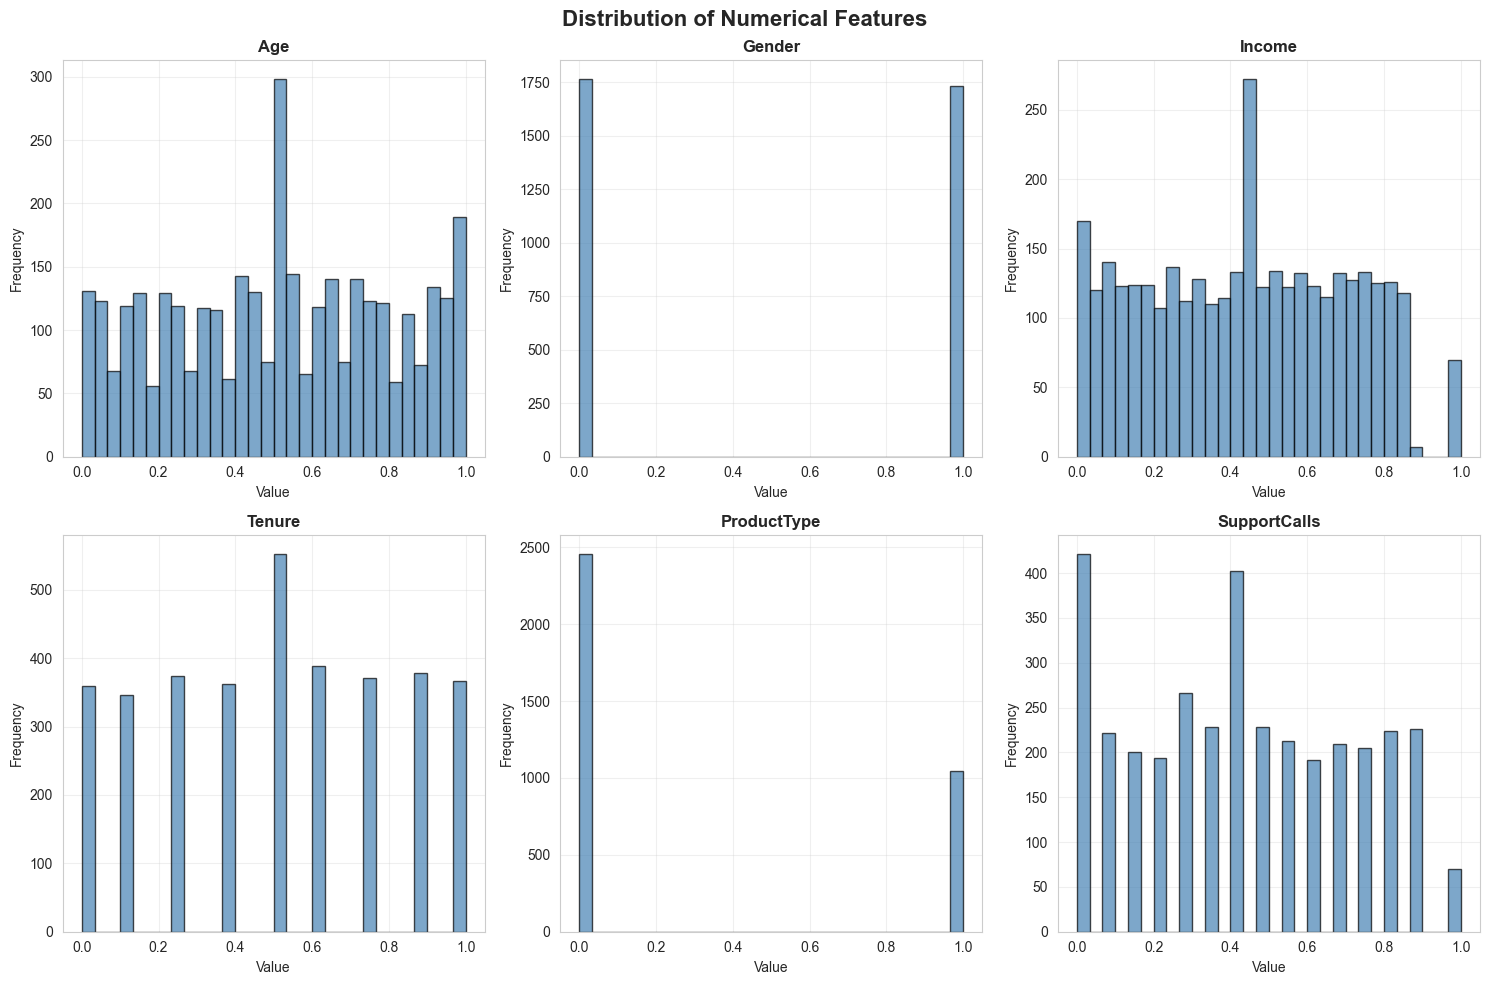

✓ Visualization 1 created successfully


In [23]:
print("" + "="*70)
print("STEP 6: DATA VISUALIZATIONS")
print("="*70)

print("Visualization 1: Distribution of Numerical Features (Histograms)")

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['CustomerID', 'ChurnStatus']]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

if len(numeric_cols) < 6:
    for idx in range(len(numeric_cols), 6):
        axes[idx].axis('off')

plt.tight_layout()
plt.show()
print("✓ Visualization 1 created successfully")

Visualization 2: Box Plots for Outlier Detection


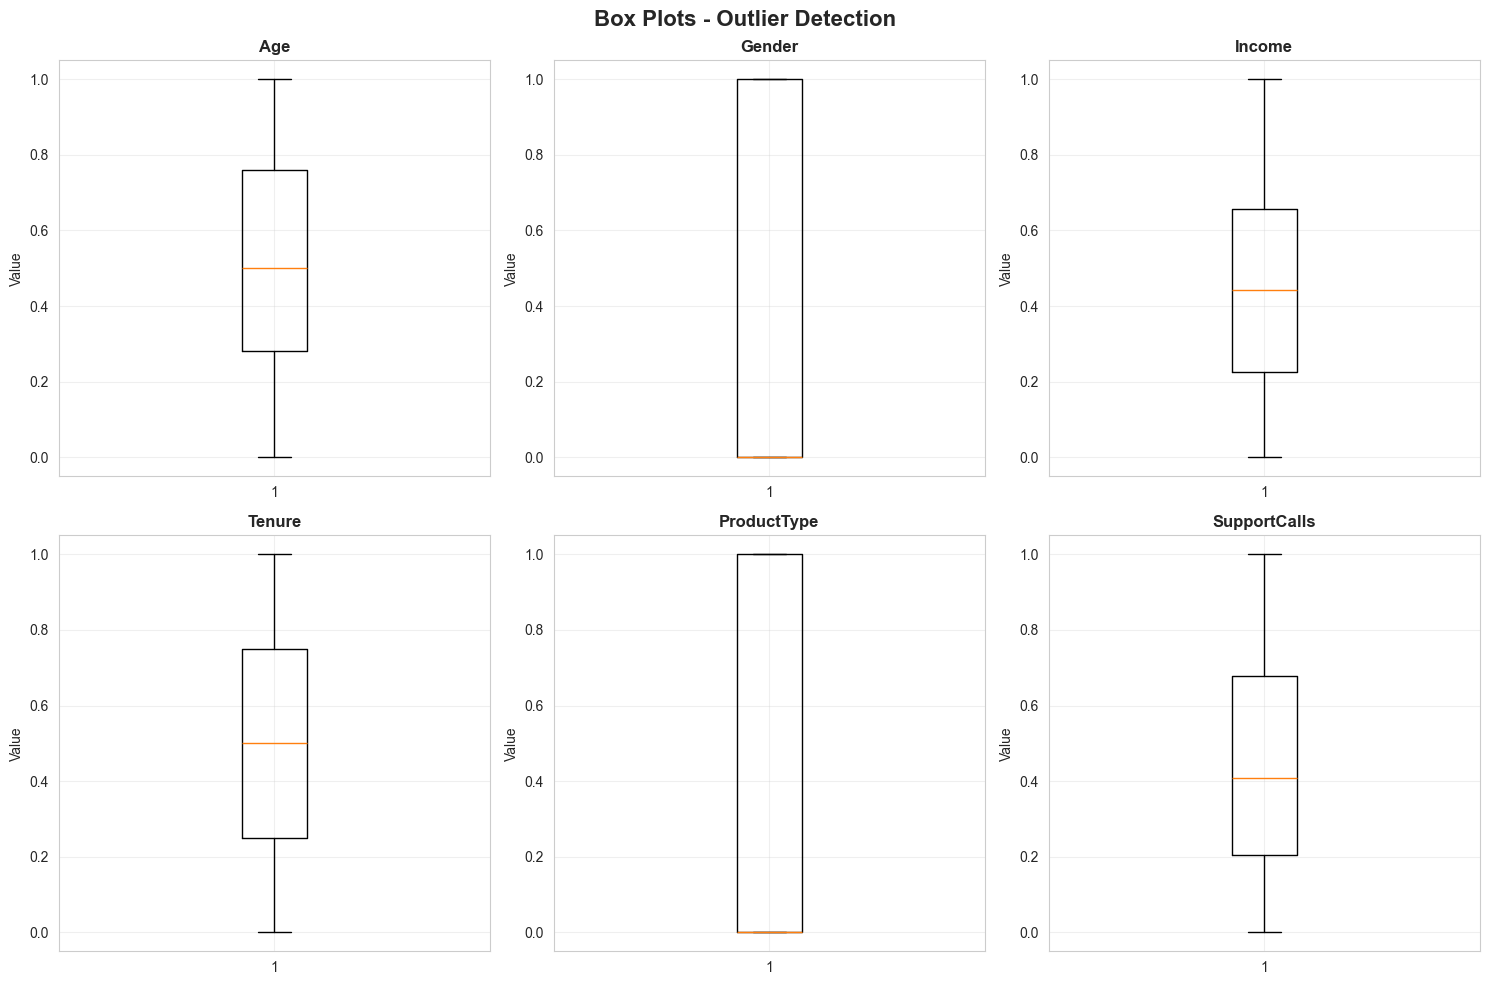

✓ Visualization 2 created successfully


In [24]:
print("Visualization 2: Box Plots for Outlier Detection")

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['CustomerID', 'ChurnStatus']]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

if len(numeric_cols) < 6:
    for idx in range(len(numeric_cols), 6):
        axes[idx].axis('off')

plt.tight_layout()
plt.show()
print("✓ Visualization 2 created successfully")

Visualization 3: Correlation Heatmap


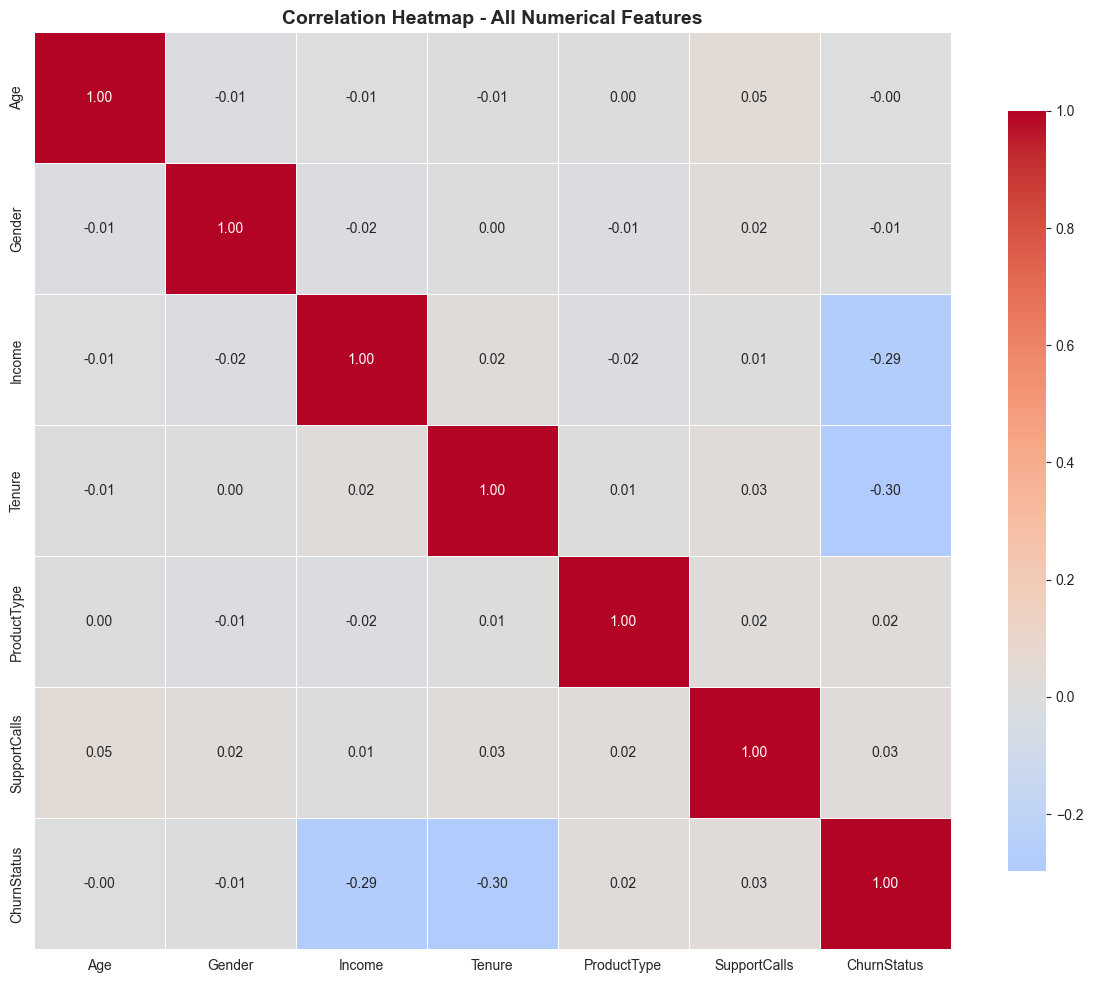

Visualization 3 created successfully


In [25]:
print("Visualization 3: Correlation Heatmap")

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['CustomerID']]

correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - All Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Visualization 3 created successfully")

Visualization 4: Churn Status Distribution & Feature Comparison


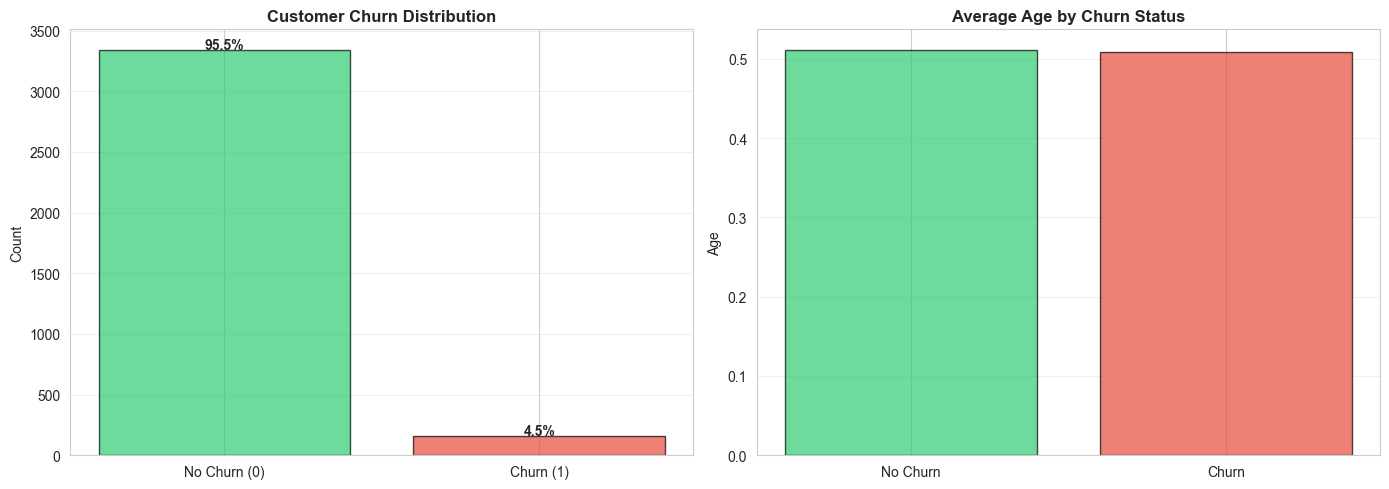

Visualization 4 created successfully


In [26]:
print("Visualization 4: Churn Status Distribution & Feature Comparison")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn distribution
churn_counts = df['ChurnStatus'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_title('Customer Churn Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

# Add percentages
for i, (idx, val) in enumerate(churn_counts.items()):
    percentage = (val / len(df)) * 100
    axes[0].text(i, val + 10, f'{percentage:.1f}%', ha='center', fontweight='bold')

# Key feature vs Churn (Tenure as example)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['CustomerID', 'ChurnStatus']]

if len(numeric_cols) > 0:
    first_feature = numeric_cols[0]
    feature_churn = df.groupby('ChurnStatus')[first_feature].mean()
    axes[1].bar(['No Churn', 'Churn'], feature_churn.values, color=colors, edgecolor='black', alpha=0.7)
    axes[1].set_title(f'Average {first_feature} by Churn Status', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(first_feature)
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("Visualization 4 created successfully")